Zadanie 10
Grid Search dla Ridge
Wczytaj California Housing. Użyj GridSearchCV do znalezienia optymalnego alpha dla
Ridge spośród [0.001, 0.01, 0.1, 1, 10, 100, 1000]. Narysuj wykres train vs CV score.
Dataset: sklearn.datasets.fetch_california_housing()

Wymagania:
GridSearchCV z cv=5, return_train_score=True
Wykres: alpha (log scale) vs train/CV R²
Zaznacz optymalne alpha

Oczekiwany rezultat: Wykres + optymalne parametry

Najlepsze alpha: 0.001
Najlepszy średni CV R²: 0.6113
Test R² dla modelu z best_alpha: 0.5758


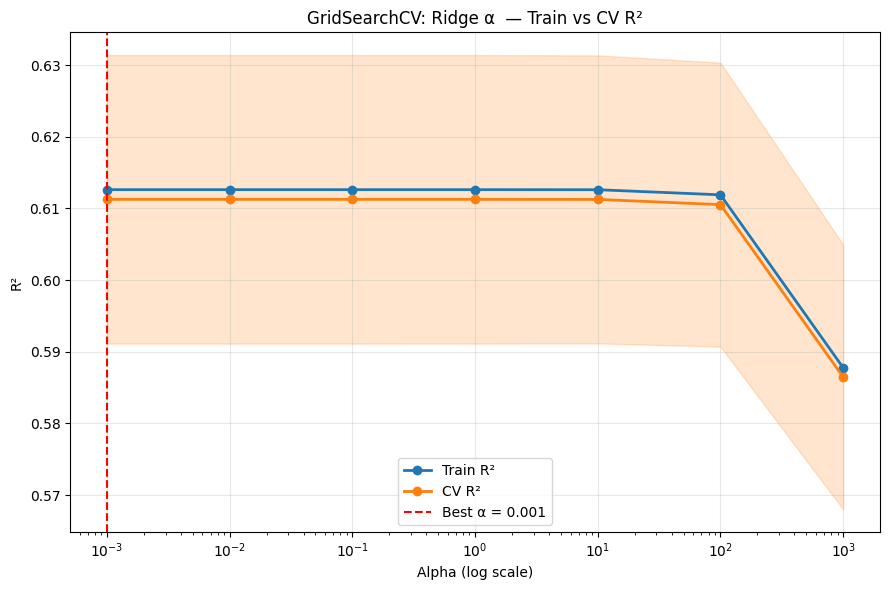

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import r2_score

# Wczytanie danych
data = fetch_california_housing(as_frame=True)
X = data.data
y = data.target

# Podział (opcjonalny, nie wymagany do GridSearch ale pomoże ocenie finalnej)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Pipeline: scaler + Ridge
pipeline = Pipeline([('scaler', StandardScaler()), ('ridge', Ridge())])

# Siatka alpha (dokładnie: [0.001,0.01,0.1,1,10,100,1000])
param_grid = {'ridge__alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000]}

# GridSearchCV
gs = GridSearchCV(
    pipeline,
    param_grid,
    cv=10,
    scoring='r2',
    return_train_score=True,
    n_jobs=-1
)
gs.fit(X_train, y_train)

# Wyniki i najlepsze parametry
best_alpha = gs.best_params_['ridge__alpha']
best_cv_r2 = gs.best_score_
print(f"Najlepsze alpha: {best_alpha}")
print(f"Najlepszy średni CV R²: {best_cv_r2:.4f}")

# Ewaluacja na zbiorze testowym
y_pred_test = gs.predict(X_test)
test_r2 = r2_score(y_test, y_pred_test)
print(f"Test R² dla modelu z best_alpha: {test_r2:.4f}")

# Przygotowanie danych do wykresu
results = pd.DataFrame(gs.cv_results_)
alphas = results['param_ridge__alpha'].astype(float)
train_scores = results['mean_train_score']   # R² (train)
cv_scores = results['mean_test_score']       # R² (CV)
cv_stds = results['std_test_score']

# Sort by alpha (ensure correct order)
order = np.argsort(alphas)
alphas = alphas.iloc[order].to_numpy()
train_scores = train_scores.iloc[order].to_numpy()
cv_scores = cv_scores.iloc[order].to_numpy()
cv_stds = cv_stds.iloc[order].to_numpy()

# Wykres: alpha (log) vs Train/CV R²
plt.figure(figsize=(9,6))
plt.semilogx(alphas, train_scores, 'o-', label='Train R²', linewidth=2, markersize=6)
plt.semilogx(alphas, cv_scores, 'o-', label='CV R²', linewidth=2, markersize=6, color='C1')
plt.fill_between(alphas, cv_scores - cv_stds, cv_scores + cv_stds, color='C1', alpha=0.2)
plt.axvline(best_alpha, color='red', linestyle='--', label=f'Best α = {best_alpha}')
plt.xlabel('Alpha (log scale)')
plt.ylabel('R²')
plt.title('GridSearchCV: Ridge α  — Train vs CV R²')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


Porównanie regularyzacji na różnych datasetach
Porównaj Ridge, Lasso i ElasticNet na dwóch datasetach: California Housing i Boston
Housing (użyj make_regression jeśli Boston niedostępny). Dla każdego datasetu znajdź
optymalne hiperparametry przez CV.
Dataset: California Housing + make_regression(n_samples=500, n_features=20,n_informative=10)

Wymagania:
RidgeCV, LassoCV, ElasticNetCV
Porównaj R² i liczbę niezerowych cech
Który model najlepszy dla którego datasetu?

Oczekiwany rezultat: Tabela porównawcza + wnioski



In [4]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing, make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score

np.random.seed(42)

def run_models(X, y, dataset_name):
    # split
    X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)
    scaler = StandardScaler()

    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    # common alphas (logspace)
    alphas = np.logspace(-4, 4, 50)

    results = []

    # RidgeCV (L2)
    ridge_cv = RidgeCV(alphas=alphas, cv=5, scoring='r2')
    ridge_cv.fit(X_train_s, y_train)
    y_pred = ridge_cv.predict(X_test_s)
    r2 = r2_score(y_test, y_pred)
    
    # Ridge keeps all features (nonzero count ~ n_features)
    n_nonzero = np.sum(np.abs(ridge_cv.coef_) > 1e-8)
    results.append({
        'dataset': dataset_name,
        'model': 'Ridge',
        'best_alpha': float(ridge_cv.alpha_),
        'test_R2': float(r2),
        'n_nonzero': int(n_nonzero)
    })

    # LassoCV (L1)
    lasso_cv = LassoCV(alphas=alphas, cv=5, random_state=42, max_iter=10000)
    lasso_cv.fit(X_train_s, y_train)
    y_pred = lasso_cv.predict(X_test_s)
    r2 = r2_score(y_test, y_pred)
    n_nonzero = np.sum(np.abs(lasso_cv.coef_) > 1e-6)
    results.append({
        'dataset': dataset_name,
        'model': 'Lasso',
        'best_alpha': float(lasso_cv.alpha_),
        'test_R2': float(r2),
        'n_nonzero': int(n_nonzero)
    })

    # ElasticNetCV (L1+L2)
    # test a few l1_ratio values
    enet_cv = ElasticNetCV(alphas=alphas, l1_ratio=[0.1,0.3,0.5,0.7,0.9,1.0],
                           cv=5, random_state=42, max_iter=10000)
    enet_cv.fit(X_train_s, y_train)
    y_pred = enet_cv.predict(X_test_s)
    r2 = r2_score(y_test, y_pred)
    n_nonzero = np.sum(np.abs(enet_cv.coef_) > 1e-6)
    results.append({
        'dataset': dataset_name,
        'model': 'ElasticNet',
        'best_alpha': float(enet_cv.alpha_),
        'best_l1_ratio': float(enet_cv.l1_ratio_),
        'test_R2': float(r2),
        'n_nonzero': int(n_nonzero)
    })

    return results

# --- Datasets ---
# 1) California Housing
cal = fetch_california_housing()
X_cal, y_cal = cal.data, cal.target

# 2) Synthetic regression (replacement for Boston)
X_syn, y_syn = make_regression(n_samples=500, n_features=20, n_informative=10,
                               noise=10.0, random_state=42)

# Run
res_cal = run_models(X_cal, y_cal, 'CaliforniaHousing')
res_syn = run_models(X_syn, y_syn, 'SyntheticRegression')

# Consolidate results to DataFrame
rows = res_cal + res_syn
df = pd.DataFrame(rows)
# reorder columns for readability
cols = ['dataset', 'model', 'best_alpha', 'best_l1_ratio', 'test_R2', 'n_nonzero']
df = df.reindex(columns=[c for c in cols if c in df.columns])
print("\n=== Porównanie modeli ===")
print(df.to_string(index=False, float_format='{:0.4f}'.format))

# Simple conclusions printed
for dataset in df['dataset'].unique():
    sub = df[df['dataset']==dataset].sort_values('test_R2', ascending=False)
    best = sub.iloc[0]
    print(f"\nDataset: {dataset} -> Best model by Test R²: {best['model']} (R²={best['test_R2']:.4f})")
    print("Model ranking (by Test R²):")
    for _, r in sub.iterrows():
        nz = r['n_nonzero'] if 'n_nonzero' in r else 'N/A'
        l1 = r.get('best_l1_ratio', '')
        print(f" - {r['model']}: R²={r['test_R2']:.4f}, alpha={r['best_alpha']:.4g}, l1_ratio={l1}, nonzero={nz}")



=== Porównanie modeli ===
            dataset      model  best_alpha  best_l1_ratio  test_R2  n_nonzero
  CaliforniaHousing      Ridge      0.0001            NaN   0.5758          8
  CaliforniaHousing      Lasso      0.0007            NaN   0.5765          8
  CaliforniaHousing ElasticNet      0.0007         1.0000   0.5765          8
SyntheticRegression      Ridge      0.1265            NaN   0.9948         20
SyntheticRegression      Lasso      0.2683            NaN   0.9949         15
SyntheticRegression ElasticNet      0.2683         1.0000   0.9949         15

Dataset: CaliforniaHousing -> Best model by Test R²: Lasso (R²=0.5765)
Model ranking (by Test R²):
 - Lasso: R²=0.5765, alpha=0.0006551, l1_ratio=nan, nonzero=8
 - ElasticNet: R²=0.5765, alpha=0.0006551, l1_ratio=1.0, nonzero=8
 - Ridge: R²=0.5758, alpha=0.0001, l1_ratio=nan, nonzero=8

Dataset: SyntheticRegression -> Best model by Test R²: Lasso (R²=0.9949)
Model ranking (by Test R²):
 - Lasso: R²=0.9949, alpha=0.2683, l1